# AncestryClassifier — Colab Training

Run preprocessing locally with Snakemake first:
```bash
snakemake --cores 4 prepare_training_data simulate_admixed
```
Upload `data/dataset.h5` and `data/admixed_test.h5` to Google Drive, then set `DRIVE_DIR` below.

**After any runtime restart: re-run Cell 1 (config) before running any other cell.**

In [31]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR     = '/content/drive/MyDrive/gene461'          
REPO          = '/content/gene_461_final_project'
WINDOW_SIZE   = 500

DATA_H5       = f'{DRIVE_DIR}/dataset.h5'
ADMIXED_H5    = f'{DRIVE_DIR}/admixed_test.h5'
CKPT_OUT      = f'{DRIVE_DIR}/checkpoints/best_model.pt'
CONFUSION_OUT = f'{DRIVE_DIR}/confusion_matrix.png'
KARYOGRAM_OUT = f'{DRIVE_DIR}/lai_karyogram.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import subprocess, os

if not os.path.exists(REPO):
    subprocess.run(
        ['git', 'clone', 'https://github.com/aszatrowski/gene_461_final_project', REPO],
        check=True
    )

%pip install -q torch h5py numpy pandas scikit-learn matplotlib

In [33]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
import os
os.makedirs(f'{DRIVE_DIR}/checkpoints', exist_ok=True)

!python {REPO}/scripts/train.py \
    --data        {DATA_H5}    \
    --output      {CKPT_OUT}   \
    --window-size {WINDOW_SIZE} \
    --epochs      25           \
    --batch-size  512          \
    --num-workers 2

In [34]:
!python {REPO}/scripts/evaluate.py \
    --data        {DATA_H5}       \
    --admixed     {ADMIXED_H5}    \
    --checkpoint  {CKPT_OUT}      \
    --confusion   {CONFUSION_OUT} \
    --karyogram   {KARYOGRAM_OUT} \
    --window-size {WINDOW_SIZE}

Loaded checkpoint from epoch 25 (val_acc=0.5696)
Evaluating on test-split windows ...
Test window accuracy: 0.5681
              precision    recall  f1-score   support

         AFR       0.83      0.87      0.85     33660
         AMR       0.31      0.19      0.24     17680
         EAS       0.60      0.69      0.64     25840
         EUR       0.46      0.54      0.50     25840
         SAS       0.38      0.32      0.35     24820

    accuracy                           0.57    127840
   macro avg       0.52      0.52      0.52    127840
weighted avg       0.55      0.57      0.56    127840

Saved confusion matrix → /content/drive/MyDrive/gene461/confusion_matrix.png
Generating LAI karyogram ...
Saved LAI karyogram → /content/drive/MyDrive/gene461/lai_karyogram.png


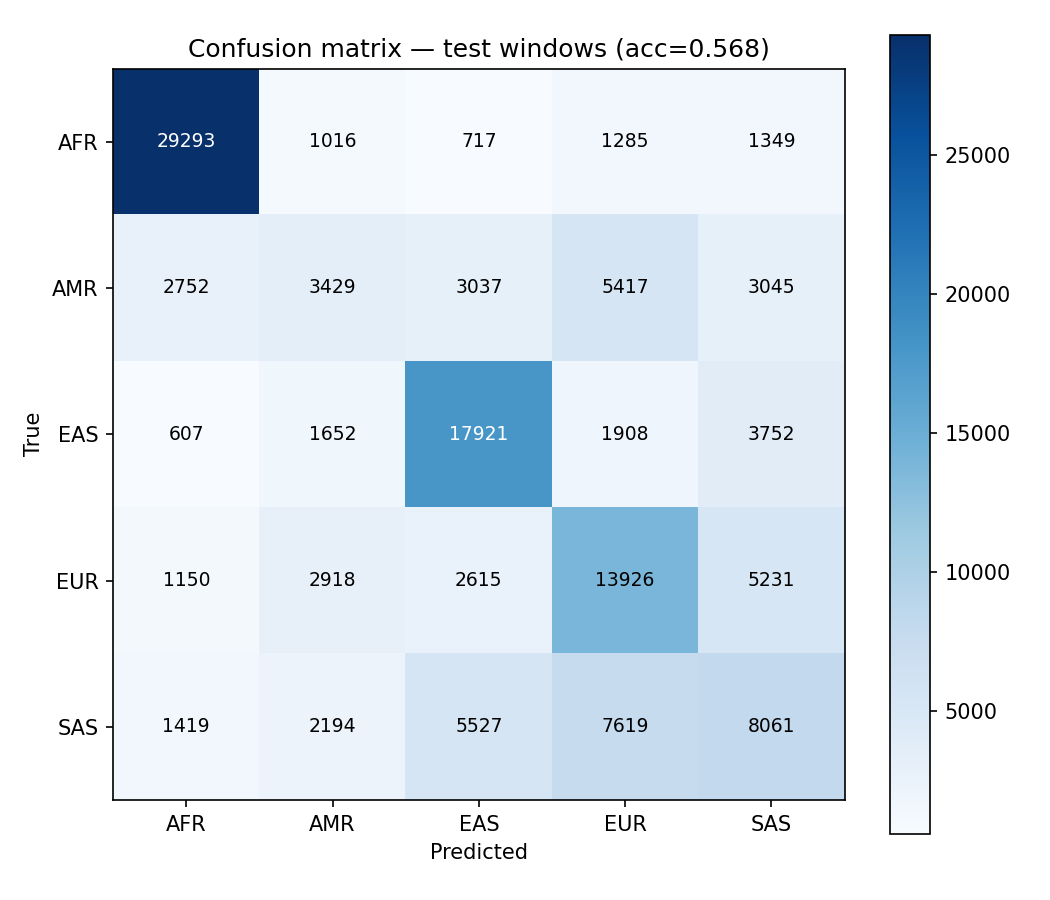

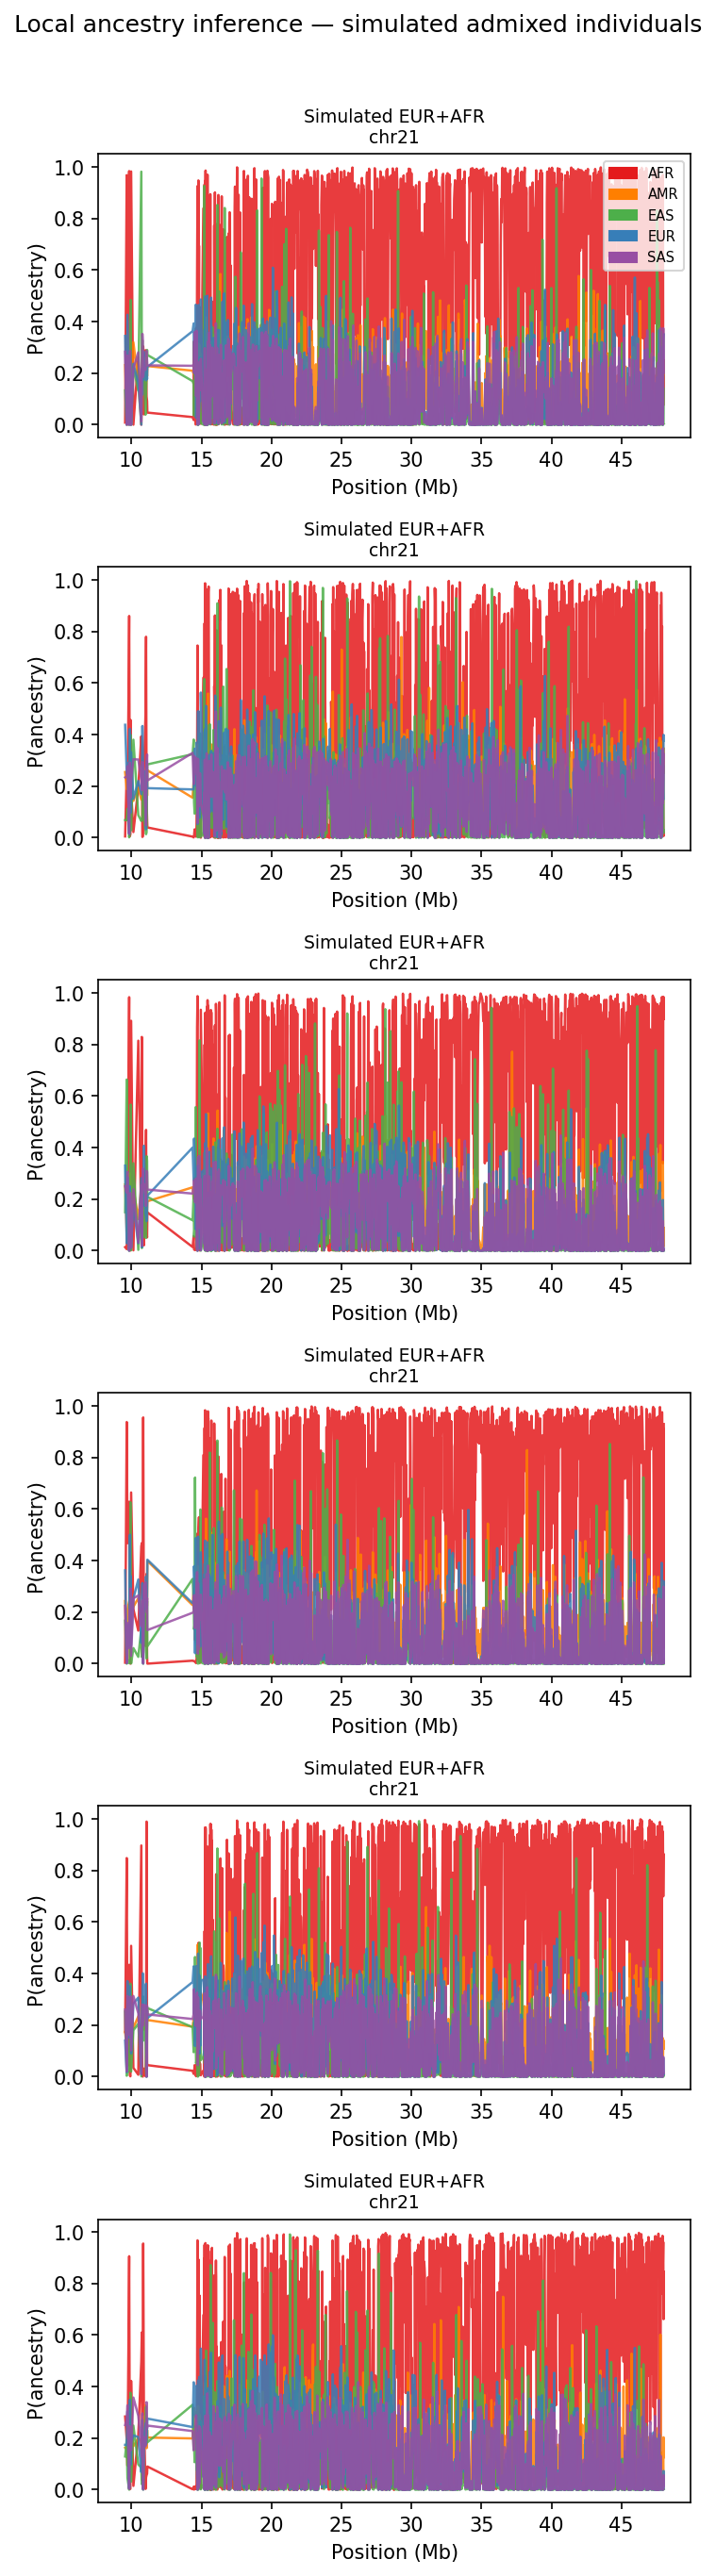

In [35]:
# ── Cell 6: display results (needs Cell 1 only) ───────────────────────────
from IPython.display import Image, display
display(Image(CONFUSION_OUT))
display(Image(KARYOGRAM_OUT))